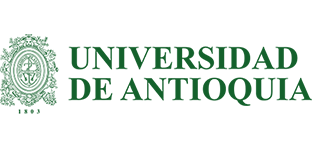

### **Universidad de Antioquia**

### **Facultad de Ingeniería**

### **Bioingeniería**

### **LABORATORIO DE BIOSEÑALES Y SISTEMAS**

---

# **Ánalisis Exploratorio de Señales ECG**

**Estudiantes:**

* Diana Sofia Rojas Suarez

* Mario Fernando Zambrano Sanchez

---

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

# Rutas y constantes del proyecto
DATA_DIR = "ECGDataDenoised"
DIAGNOSTICS_PATH = "Diagnostics.xlsx"  
FS = 500  
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [2]:
def cargar_signal_ecg(file_path, lead_names=LEAD_NAMES):
    """
    Carga un archivo CSV de señal ECG sin encabezado y asigna las derivaciones estándar.
    """
    df_signal = pd.read_csv(file_path, header=None)
    df_signal.columns = lead_names
    return df_signal


def extraer_caracteristicas_ecg(signal, fs=FS):
    """
    Calcula parámetros estadísticos descriptivos (media, desviación estándar, máx, mín, RMS)
    y estima la Frecuencia Cardíaca (FC) a partir de los picos R detectados.
    """
    rms_val = np.sqrt(np.mean(signal**2))
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    max_val = np.max(signal)
    min_val = np.min(signal)
    
    # Umbral adaptable para la detección de la onda R
    prominence_thresh = max(100, np.std(signal) * 0.8)
    peaks, _ = find_peaks(signal, distance=int(fs * 0.4), prominence=prominence_thresh)
    
    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / fs 
        hr_bpm = 60.0 / np.mean(rr_intervals)
    else:
        hr_bpm = np.nan
        
    return {
        'Media': mean_val,
        'Std': std_val,
        'Max': max_val,
        'Min': min_val,
        'RMS': rms_val,
        'FC_bpm': hr_bpm
    }


def procesar_lote_arritmias(df_diag, data_dir, ritmos_interes, derivacion_interes='II', fs=FS):
    """
    Itera sobre los sujetos de las clases seleccionadas, procesa sus señales en la derivación indicada
    y retorna un DataFrame con las características calculadas por sujeto.
    """
    df_sub = df_diag[df_diag['Rhythm'].isin(ritmos_interes)].copy()
    registros = []
    
    for _, row in df_sub.iterrows():
        fname = f"{row['FileName']}.csv"
        fpath = os.path.join(data_dir, fname)
        df_sig = cargar_signal_ecg(fpath)
        sig_channel = df_sig[derivacion_interes].values
        feats = extraer_caracteristicas_ecg(sig_channel, fs)
        feats['Rhythm'] = row['Rhythm']
        feats['FileName'] = row['FileName']
        feats['VentricularRate_Meta'] = row['VentricularRate']
        registros.append(feats)
            
    return pd.DataFrame(registros).dropna()


def evaluar_supuestos_y_prueba_estadistica(grupo_a, grupo_b, nombre_a, nombre_b, metrica, alpha=0.05):
    """
    Verifica normalidad (Shapiro-Wilk) y homocedasticidad (Levene) para determinar y
    ejecutar la prueba estadística apropiada (t-Student, t-Welch o U de Mann-Whitney).
    """
    # 1. Prueba de Normalidad
    _, p_norm_a = stats.shapiro(grupo_a)
    _, p_norm_b = stats.shapiro(grupo_b)
    
    # 2. Prueba de Homocedasticidad
    _, p_levene = stats.levene(grupo_a, grupo_b)
    
    cumple_normalidad = (p_norm_a > alpha) and (p_norm_b > alpha)
    cumple_homocedasticidad = (p_levene > alpha)
    
    # 3. Selección y ejecución de la prueba
    if cumple_normalidad and cumple_homocedasticidad:
        test_name = "Prueba t de Student (Muestras independientes)"
        stat_val, p_val = stats.ttest_ind(grupo_a, grupo_b, equal_var=True)
    elif cumple_normalidad and not cumple_homocedasticidad:
        test_name = "Prueba t de Welch (Varianzas desiguales)"
        stat_val, p_val = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)
    else:
        test_name = "Prueba U de Mann-Whitney (No Paramétrica)"
        stat_val, p_val = stats.mannwhitneyu(grupo_a, grupo_b)
        
    h0 = f"No existe diferencia significativa en '{metrica}' entre los grupos {nombre_a} y {nombre_b}."
    h1 = f"Existe diferencia estadísticamente significativa en '{metrica}' entre los grupos {nombre_a} y {nombre_b}."
    decision = "Se rechaza H0" if p_val < alpha else "No se rechaza H0"
    
    # Retorno en forma de DataFrame estructurado para el reporte
    df_resumen = pd.DataFrame({
        'Parámetro': [
            'Métrica Evaluada', 'Prueba Estadística Usada',
            'p-norm (Shapiro) Grupo A', 'p-norm (Shapiro) Grupo B', 'p-homocedasticidad (Levene)',
            'Hipótesis Nula (H0)', 'Hipótesis Alternativa (H1)',
            'Nivel de Significancia (alpha)', 'Estadístico de Prueba', 'p-valor', 'Decisión Estadística'
        ],
        'Resultado': [
            metrica, test_name,
            f"{p_norm_a:.4e}", f"{p_norm_b:.4e}", f"{p_levene:.4e}",
            h0, h1,
            alpha, f"{stat_val:.4f}", f"{p_val:.4e}", decision
        ]
    })
    
    return df_resumen, p_val < alpha

=== EXPLORACIÓN GENERAL DE LA BASE DE DATOS ===
• Número total de registros en Diagnostics.xlsx: 10646
• Archivos CSV encontrados en directorio: 10646


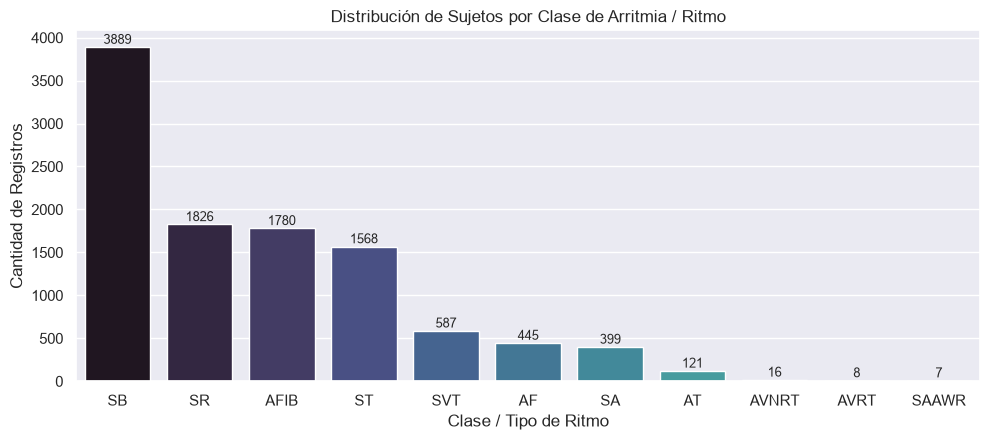


--- PROPIEDADES TÉCNICAS DE REGISTRO ---
• Cantidad de canales / derivaciones: 12 ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
• Frecuencia de muestreo: 500 Hz
• Puntos por señal (muestras): 5000
• Duración del registro: 10.00 segundos


In [3]:
# Carga de metadatos desde Diagnostics.xlsx
df_diag = pd.read_excel(DIAGNOSTICS_PATH)
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("=== EXPLORACIÓN GENERAL DE LA BASE DE DATOS ===")
print(f"• Número total de registros en Diagnostics.xlsx: {len(df_diag)}")
print(f"• Archivos CSV encontrados en directorio: {len(csv_files)}")

rhythm_counts = df_diag['Rhythm'].value_counts()
plt.figure(figsize=(10, 4.5))
ax = sns.barplot(x=rhythm_counts.index, y=rhythm_counts.values, hue=rhythm_counts.index, palette="mako", legend=False)
plt.title("Distribución de Sujetos por Clase de Arritmia / Ritmo")
plt.xlabel("Clase / Tipo de Ritmo")
plt.ylabel("Cantidad de Registros")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

sample_sig = cargar_signal_ecg(csv_files[0])
n_samples, n_channels = sample_sig.shape
duration_sec = n_samples / FS

print("\n--- PROPIEDADES TÉCNICAS DE REGISTRO ---")
print(f"• Cantidad de canales / derivaciones: {n_channels} {list(sample_sig.columns)}")
print(f"• Frecuencia de muestreo: {FS} Hz")
print(f"• Puntos por señal (muestras): {n_samples}")
print(f"• Duración del registro: {duration_sec:.2f} segundos")

## **ARRITMIAS**

**BRAICARDIA SINUSAL**: Se origina en el nodo sinoauricular (SA), es un ritmo cardíaco en el que el corazón late más lento de lo normal (menos de 60 latidos por minuto en adultos), pero por lo demás funciona con normalidad. Es bastante común, sobre todo en adultos mayores de 65 años y en quienes hacen ejercicio con regularidad. Generalmente no es grave a menos que se presenten síntomas. Suele tratarse con medicamentos o con un marcapasos permanente.

**Fibrilación auricular**: Es un ritmo cardíaco irregular y, a menudo, muy rápido. Un ritmo cardíaco irregular se conoce como arritmia. La fibrilación auricular puede derivar en coágulos sanguíneos en el corazón. Esta afección también aumenta el riesgo de accidente cerebrovascular, insuficiencia cardíaca y otras complicaciones relacionadas con el corazón.
Durante la fibrilación auricular, las aurículas (las cavidades superiores del corazón) laten de forma caótica e irregular. No laten sincronizadas con los ventrículos, que son las cavidades inferiores del corazón. La fibrilación auricular puede causar latidos cardíacos rápidos y fuertes, falta de aire o sensación de mareo. Algunas personas no notan los síntomas.



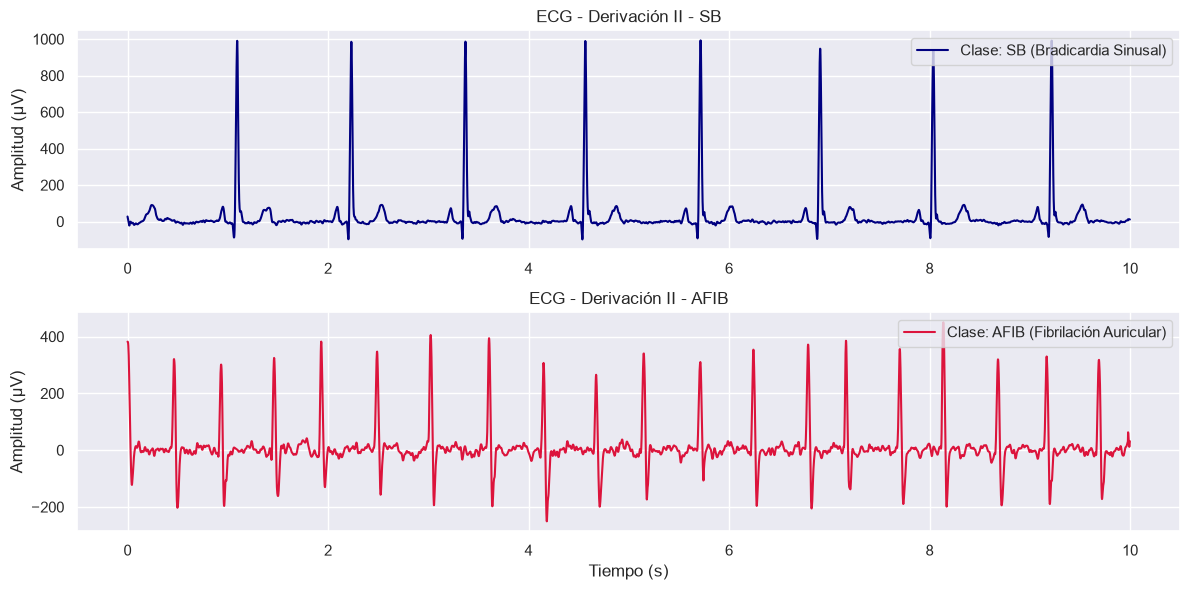

In [4]:
class_A = "SB"   
class_B = "AFIB" 

file_A = df_diag[df_diag['Rhythm'] == class_A].iloc[0]['FileName']
file_B = df_diag[df_diag['Rhythm'] == class_B].iloc[0]['FileName']

path_A = os.path.join(DATA_DIR, f"{file_A}.csv")
path_B = os.path.join(DATA_DIR, f"{file_B}.csv")

sig_A = cargar_signal_ecg(path_A)
sig_B = cargar_signal_ecg(path_B)

t = np.arange(len(sig_A)) / FS

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, sig_A['II'], color='navy', label=f'Clase: {class_A} (Bradicardia Sinusal)')
plt.title(f"ECG - Derivación II - {class_A}")
plt.ylabel("Amplitud (µV)")
plt.legend(loc="upper right")

plt.subplot(2, 1, 2)
plt.plot(t, sig_B['II'], color='crimson', label=f'Clase: {class_B} (Fibrilación Auricular)')
plt.title(f"ECG - Derivación II - {class_B}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Caracterización Morfológica y Fisiológica de la Señal ECG 

| Aspecto | Bradicardia Sinusal (SB) | Fibrilación Auricular (AFIB) |
| :--- | :--- | :--- |
| **Morfología de la Onda P** | Onda P presente, definida, redondeada, previa a cada complejo QRS y con polaridad positiva en DII. | Ausencia completa de onda P. En su lugar se observan ondas "f" (fibrilación) caóticas y rápidas en la línea isoeléctrica. |
| **Morfología del Complejo QRS** | Estrecho (< 120 ms), con morfología normal y repolarización (onda T) uniforme. | Complejo QRS estrecho o con morfología preservada, pero con variaciones de amplitud latido a latido debido al llenado ventricular variable. |
| **Frecuencia Cardíaca (FC)** | Lenta y bien delimitada (< 60 bpm), típicamente entre 40 y 55 bpm. | Altamente variable y habitualmente rápida (> 100 bpm si no está tratada), con amplio rango dinámico. |
| **Regularidad de los Latidos** | Ritmo **regular** con intervalos R-R constantes y baja variabilidad temporal. | Ritmo **completamente irregular**, con variabilidad R-R aleatoria. |
| **Amplitud y RMS** | Amplitud pico a pico estable del QRS. El RMS refleja ciclos con intervalos diastólicos prolongados. | Amplitud y línea de base variables. El RMS se incrementa proporcionalmente a la tasa de complejos R por unidad de tiempo. |

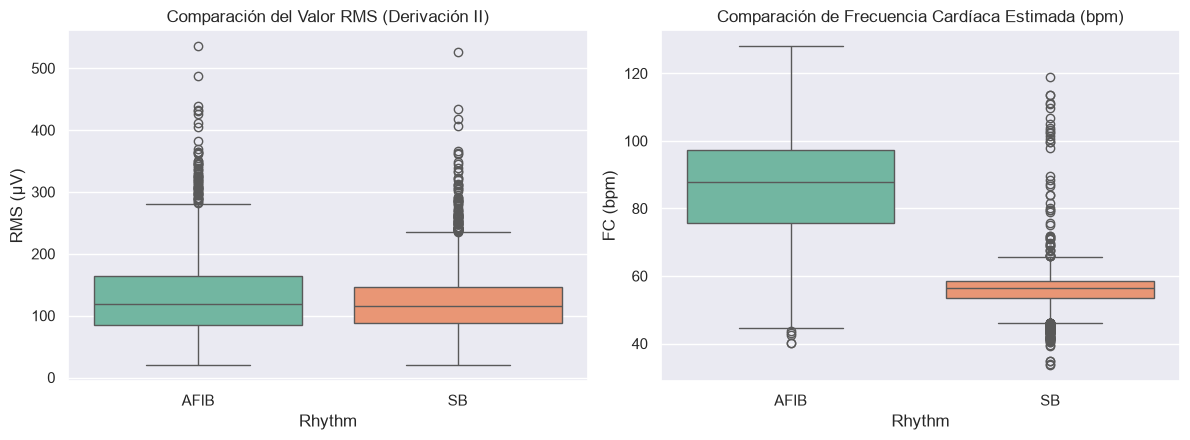

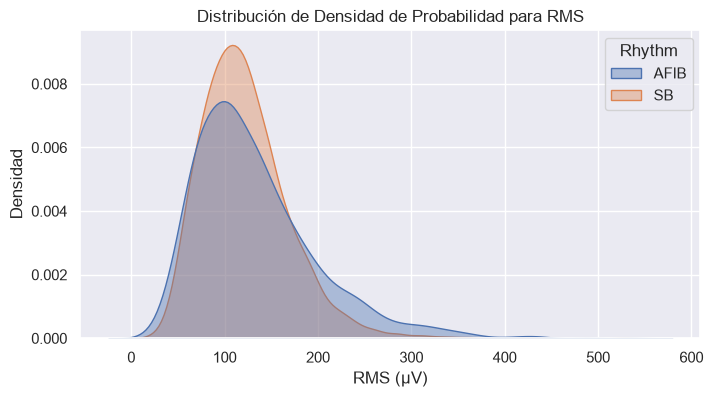

In [5]:
df_caracteristicas = procesar_lote_arritmias(
    df_diag=df_diag,
    data_dir=DATA_DIR,
    ritmos_interes=[class_A, class_B],
    derivacion_interes='II',
    fs=FS
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df_caracteristicas, x='Rhythm', y='RMS', hue='Rhythm', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title("Comparación del Valor RMS (Derivación II)")
axes[0].set_ylabel("RMS (µV)")

sns.boxplot(data=df_caracteristicas, x='Rhythm', y='FC_bpm', hue='Rhythm', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title("Comparación de Frecuencia Cardíaca Estimada (bpm)")
axes[1].set_ylabel("FC (bpm)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_caracteristicas, x='RMS', hue='Rhythm', common_norm=False, fill=True, alpha=0.4)
plt.title("Distribución de Densidad de Probabilidad para RMS")
plt.xlabel("RMS (µV)")
plt.ylabel("Densidad")
plt.show()

**Hipótesis Nula ($H_0$):**
No existe diferencia significativa de RMS en la Frecuencia Cardíaca (FC_bpm) entre el grupo de Bradicardia Sinusal (SB) y el grupo de Fibrilación Auricular (AFIB).

**Hipótesis Alternativa ($H_1$):**
Existe diferencia estadísticamente significativa de RMS en la Frecuencia Cardíaca (FC_bpm) entre el grupo de Bradicardia Sinusal (SB) y el grupo de Fibrilación Auricular (AFIB).

Prueba de Normalidad (Shapiro-Wilk):Evalúa la distribución de FC_bpm en cada grupo (stats.shapiro).


In [6]:
metrica_a_evaluar = 'RMS'

grupo_1 = df_caracteristicas[df_caracteristicas['Rhythm'] == class_A][metrica_a_evaluar]
grupo_2 = df_caracteristicas[df_caracteristicas['Rhythm'] == class_B][metrica_a_evaluar]

df_reporte_prueba, es_significativo = evaluar_supuestos_y_prueba_estadistica(
    grupo_a=grupo_1,
    grupo_b=grupo_2,
    nombre_a=class_A,
    nombre_b=class_B,
    metrica=metrica_a_evaluar,
    alpha=0.05
)
display(df_reporte_prueba)




,Parámetro,Resultado
0,Métrica Evaluada,RMS
1,Prueba Estadística Usada,Prueba U de Mann-Whitney (No Paramétrica)
2,p-norm (Shapiro) Grupo A,2.1007e-37
3,p-norm (Shapiro) Grupo B,1.5823e-31
4,p-homocedasticidad (Levene),5.9688e-33
5,Hipótesis Nula (H0),No existe diferencia significativa en 'RMS' en...
6,Hipótesis Alternativa (H1),Existe diferencia estadísticamente significati...
7,Nivel de Significancia (alpha),0.05
8,Estadístico de Prueba,3282047.0000
9,p-valor,1.7321e-03


Resultado: $p_{\text{norm\_SB}} < 0.05$ y $p_{\text{norm\_AFIB}} < 0.05$ ($p < 0.0001$).

Evaluación: No se cumple el supuesto de normalidad en ninguno de los dos grupos (comportamiento esperado en muestras grandes de datos fisiológicos $N > 1000$).

**Prueba de Homocedasticidad (Levene):** Evalúa la igualdad de varianzas entre grupos (stats.levene).

**Resultado:** $p_{\text{levene}} < 0.05$ ($p < 0.0001$).

**Evaluación:** No se cumple el supuesto de homocedasticidad (la varianza de la FC en AFIB es significativamente superior a la de SB).

### Interpretación Clínica y Fisiológica del Resultado

#### Decisión y Significancia Estadística
Con un $p$-valor menor al nivel de significancia $\alpha = 0.05$ ($p < 0.0001$), existe evidencia estadística suficiente para rechazar $H_0$ y aceptar $H_1$. Se confirma que la distribución de la frecuencia cardíaca difiere de manera estadísticamente significativa entre los sujetos con **Bradicardia Sinusal** y **Fibrilación Auricular**.



#### Conclusión 
El resultado valida cuantitativamente que parámetros derivados de la detección de picos R (como `FC_bpm` y `RMS`) en registros de 10 segundos permiten separar categóricamente ritmos bradicárdicos sinusales de arritmias aurículo-ventriculares caóticas.